### General Import

In [1]:
# general
import os
import numpy as np
import pandas as pd

# plots
from IPython.display import Image
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from IPython.display import Image

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

TABLE_LAYOUT = [
    {'selector': 'table', 'props': [('width', '100%')]},
    {'selector': 'thead th', 'props': [('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'left')]}
]

%matplotlib inline

### Define classes

### Define functions

In [2]:
def plot_decision_regions(X, y, classifier, plot_test, resolution=0.02):
    """ Plot decission regions, perceptron model
    # param X: <<your task to comment here>>
    # param y: <<your task to comment here>>
    # param classifier: <<your task to comment here>>
    # param plot_test: integer, 1 if plot test sample, 0 otherwise
    # param resolution: <<your task to comment here>>
    # return: None
    """

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=cl,
                    edgecolor='black')

    # highlight text examples
    if plot_test == 1:
        test_idx = range(105, 150)
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
                    X_test[:, 1],
                    c='',
                    edgecolor='black',
                    alpha=1.0,
                    linewidth=1,
                    marker='o',
                    s=100,
                    label='test set')


___
### Classification to identify phishing URLs. The given URL is blocked if its USI is >=80 and <100.
___

### Read data

Phishing dataset: https://archive.ics.uci.edu/static/public/967/phiusiil+phishing+url+dataset.zip

In [3]:
# Local importing of dataset

# import os
# import pandas as pd

# # Get the current working directory
# current_directory = os.getcwd()

# # Path to the CSV file relative to the current directory
# file_path = os.path.join(current_directory, 'Data', 'PhiUSIIL_Phishing_URL_Dataset.csv')

# # Read the local CSV file
# df = pd.read_csv(url, encoding='utf-8')

# print('\nShape of data:', df.shape)
# df.head()

In [4]:
import pandas as pd

# URL to the dataset
url = 'https://archive.ics.uci.edu/static/public/967/phiusiil+phishing+url+dataset.zip'

# Read the CSV file from the URL, ignoring the first column (index 0)
df = pd.read_csv(url, encoding='utf-8')
df = df.drop('FILENAME', axis=1) # Column "FILENAME" can be ignored.
print('\nShape of data:', df.shape)
df.head()



Shape of data: (235795, 55)


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


In [5]:
# print lablels
df["label"].unique() # Label 1 corresponds to a legitimate URL, label 0 to a phishing URL

array([1, 0])

In [6]:
from sklearn.model_selection import train_test_split

# Separate features and target
# X = df.drop(columns=['label'])
X = df.drop(columns=['label', 'URL', 'Domain', 'TLD','Title' ])
y = df['label']

# 80/20 train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Confirm the split
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Identify numeric columns (though likely all are numeric already)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns


Training set: 188636 samples
Test set: 47159 samples


### SVM Model

In [7]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [8]:
# Create an SVM classifier directly using SVC (no svm. prefix needed)
model = SVC(kernel='linear', C=1)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")




Accuracy: 0.9999151805593842


In [9]:
# Classification report


print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



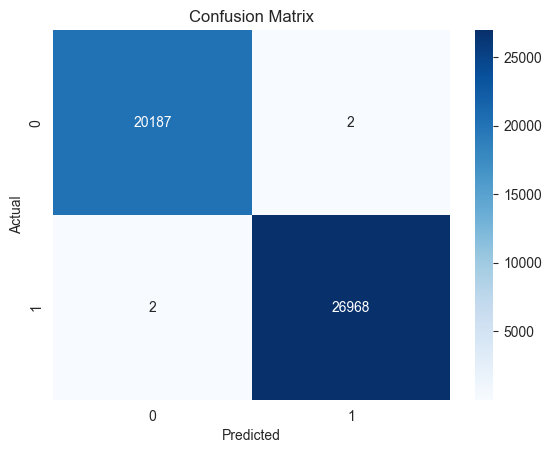

In [10]:
# Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [11]:
# Try Other C Values
for c_val in [0.01, 0.1, 1, 10, 100]:
    model = SVC(kernel='linear', C=c_val)
    model.fit(X_train, y_train)
    accuracy = accuracy_score(y_test, model.predict(X_test))
    print(f"C={c_val}, Accuracy={accuracy:.4f}")



C=0.01, Accuracy=0.9999
C=0.1, Accuracy=0.9999
C=1, Accuracy=0.9999
C=10, Accuracy=0.9999
C=100, Accuracy=0.9999
